# Alterações

- RNN espera uma entrada no formato (batch, timesteps, features): (1, 6, 2).

- No controle, o "timestep" para a predição imediata costuma ser o estado atual e a ação de controle.

- Necessidade de normalização antes do $predict$ e desnormalizar após.

- Se o tempo de cálculo explodir, tente converter o modelo para ONNX ou usar apenas as matrizes de pesos da rede para cálculo direto com NumPy. 

In [2]:
import numpy as np

# Normalização
meanX = np.array([11.54549372, 12.4514907])
stdX = np.array([4.23449211, 3.9104502])
meanY = np.array([ 3.07519347, 46.57397573])
stdY = np.array([2.11485258, 3.02168235])
def std(x):
    return (x - meanX) / stdX
def destd(y_norm):
    return (y_norm * stdY) + meanY

# Teste H5

Tempo de Execução:  2.604 [s]


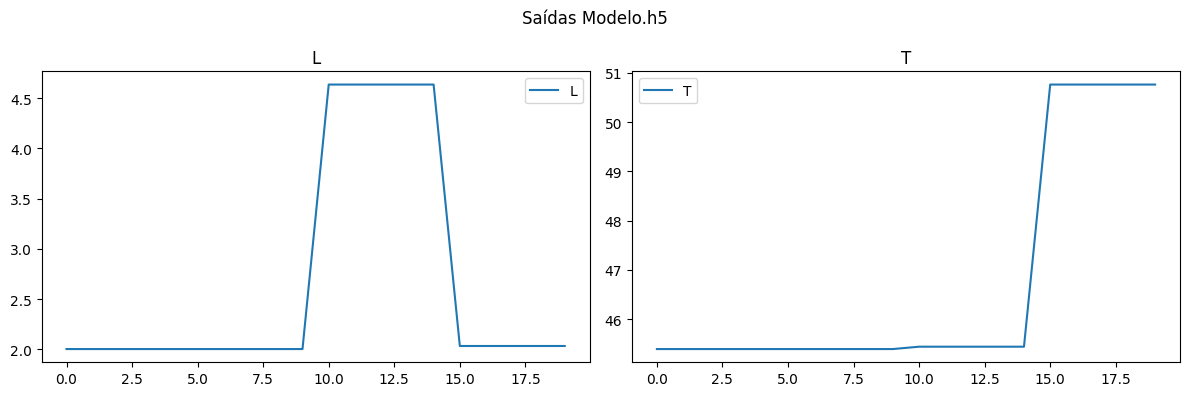

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
import time

# Carregar modelo 
model = load_model("model_JT.h5", compile=False)

# Passos de simulação
N = 20

# entrada: [Fi, Fv]
u = np.zeros((N, 2))
A, B = int(N/2), int(3*N/4)
#
u[:, 0] = 10.0
u[A:, 0] = 15.0 
u[B:, 0] = 10.0 
# 
u[:, 1] = 10.0
u[A:, 1] = 15.0
u[B:, 1] = 20.0 

# normalizar entrada
u_norm = std(u)

# armazenar saída
y_pred = np.zeros((N, 2))

# histórico inicial (TIME_STEPS = 1)
x_input = np.zeros((1, 1, 2))  # (batch, time_steps, features)

start_time = time.time() 
for k in range(N):

    # entrada atual
    x_input[0, 0, :] = u_norm[k]
    # print(f'IN =', x_input)
    # predição
    yk = model.predict(x_input, verbose=0)
    # print(f'OUT =', yk)
    # salvar
    y_pred[k] = yk[0]
Tempo_exec = (time.time() - start_time)
print(f'Tempo de Execução: ', "%.3f" % Tempo_exec, '[s]')

# desnormalizar saída
y_pred_real = destd(y_pred)

# ------------ PLOT ----------------
plt.figure(figsize=(12,4))
plt.suptitle('Saídas Modelo.h5', fontsize=12)

plt.subplot(1,2,1)
plt.plot(y_pred_real[:,0], label="L")
plt.title("L")
plt.legend()

plt.subplot(1,2,2)
plt.plot(y_pred_real[:,1], label="T")
plt.title("T")
plt.legend()

plt.tight_layout()
plt.show()

# Teste ONNX

Predição: 1 [ 2.00253948 45.39287173]
Predição: 2 [ 2.00253948 45.39287173]
Predição: 3 [ 2.00253948 45.39287173]
Predição: 4 [ 2.00253948 45.39287173]
Predição: 5 [ 2.00253948 45.39287173]
Predição: 6 [ 2.00253948 45.39287173]
Predição: 7 [ 2.00253948 45.39287173]
Predição: 8 [ 2.00253948 45.39287173]
Predição: 9 [ 2.00253948 45.39287173]
Predição: 10 [ 2.00253948 45.39287173]
Predição: 11 [ 2.00253948 45.39287173]
Predição: 12 [ 2.00253948 45.39287173]
Predição: 13 [ 2.00253948 45.39287173]
Predição: 14 [ 2.00253948 45.39287173]
Predição: 15 [ 2.00253948 45.39287173]
Predição: 16 [ 2.00253948 45.39287173]
Predição: 17 [ 2.00253948 45.39287173]
Predição: 18 [ 2.00253948 45.39287173]
Predição: 19 [ 2.00253948 45.39287173]
Predição: 20 [ 2.00253948 45.39287173]
Predição: 21 [ 2.00253948 45.39287173]
Predição: 22 [ 2.00253948 45.39287173]
Predição: 23 [ 2.00253948 45.39287173]
Predição: 24 [ 2.00253948 45.39287173]
Predição: 25 [ 2.00253948 45.39287173]
Predição: 26 [ 2.00253948 45.39287

'\n# ------------ PLOT ----------------\nplt.figure(figsize=(9.9,3))\nplt.suptitle(\'ERRO\', fontsize=12)\n\nplt.subplot(1,2,1)\nplt.plot(erro[0], label="erro_L")\nplt.title("L")\nplt.legend()\n\nplt.subplot(1,2,2)\nplt.plot(erro[1], label="erro_T")\nplt.title("T")\nplt.legend()\n\nplt.tight_layout()\nplt.show()\n'

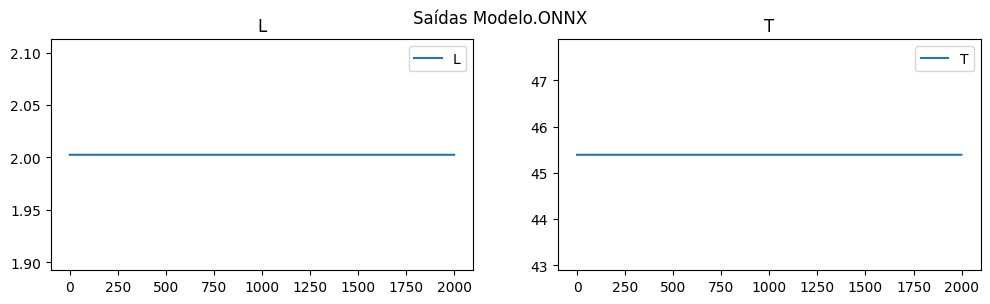

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
import onnxruntime as ort
import time
import pandas as pd

# O 'sess' (sessão) substitui o 'model_rnn'
sess = ort.InferenceSession("model_JT.onnx")

# Obter o nome da entrada (necessário para o ONNX)
input_name = sess.get_inputs()[0].name

def rnn_predict_onnx(u_atual, session):
    # --- Normalização (Z-score conforme seu scaler) ---
    u_norm = std(u_atual)
    
    # --- Preparar o input para o ONNX ---
    # Garante float32 e o shape (1, 1, 2)
    input_data = u_norm.reshape(1, 1, 2).astype(np.float32)
    
    # --- Executar a Inferência ---
    # No ONNX, passamos um dicionário com o nome da entrada
    outputs = session.run(None, {input_name: input_data})
    ypred_norm = outputs[0] # O resultado vem em uma lista
    
    # --- Desnormalização ---
    return destd(ypred_norm.flatten())

# ---------- Teste rápido -------------
N = 2000
A, B = int(N/2), int(3*N/4)

# entrada: [Fi, Fv]
u_teste = np.zeros((N, 2))

'''
# degrau em Fi
u_teste[:, 0] = 12.0   # valor inicial
u_teste[A:, 0] = 15.0 # degrau no tempo 20
u_teste[B:, 0] = 10.0 # degrau no tempo 20

# manter Fv constante
u_teste[:, 1] = 17.0
u_teste[A:, 1] = 15.0 # degrau no tempo 20
u_teste[B:, 1] = 20.0 # degrau no tempo 20
'''

# degrau em Fi
u_teste[:, 0] = 10.0   # valor inicial
u_teste[A:, 0] = 10.0 # degrau no tempo 20
u_teste[B:, 0] = 10.0 # degrau no tempo 20

# manter Fv constante
u_teste[:, 1] = 10.0
u_teste[A:, 1] = 10.0 # degrau no tempo 20
u_teste[B:, 1] = 10.0 # degrau no tempo 20

Predicao = np.zeros((N, 2))

start_time = time.time() # 1 Marca o tempo de início
for k in range(N):
    Predicao[k] = rnn_predict_onnx(u_teste[k,:], sess)
    print("Predição:", k+1, Predicao[k])

Tempo_exec = (time.time() - start_time)
print(f'Tempo de Execução: ', "%.3f" % Tempo_exec, '[s]')

data = pd.read_excel("./Dados_norma/Teste_ONNX.xlsx", header=None)

erro = abs(Predicao - data)*100/data

# ------------ PLOT ----------------
plt.figure(figsize=(12,3))
plt.suptitle('Saídas Modelo.ONNX', fontsize=12)

plt.subplot(1,2,1)
plt.plot(Predicao[:,0], label="L")
#plt.plot(data[0], label="L_real")
plt.title("L")
plt.legend()

plt.subplot(1,2,2)
plt.plot(Predicao[:,1], label="T")
#plt.plot(data[1], label="T_real")
plt.title("T")
plt.legend()

'''
# ------------ PLOT ----------------
plt.figure(figsize=(9.9,3))
plt.suptitle('ERRO', fontsize=12)

plt.subplot(1,2,1)
plt.plot(erro[0], label="erro_L")
plt.title("L")
plt.legend()

plt.subplot(1,2,2)
plt.plot(erro[1], label="erro_T")
plt.title("T")
plt.legend()

plt.tight_layout()
plt.show()
'''

# NMPC .H5

In [5]:
import numpy as np
'''
def rnn_predict(u_atual, model_rnn):
    # 1. Padroniza a entrada atual [Fi, Fv]
    u_norm = std(u_atual)
    
    # 2. Reshape para (1, 1, 2) - Batch, Timestep, Features
    input_data = np.zeros((1, 1, 2))  # (batch, time_steps, features)
    input_data[0, 0, :] = u_norm

    #print(f'IN', input_data)
    # 3. Predição
    #ypred_norm = model_rnn.predict(input_data, verbose=0)
    ypred_norm = model_rnn(input_data, training=False).numpy().flatten()
    #print(f'OUT', ypred_norm)
    # 4. Retorna em unidades físicas
    return destd(ypred_norm)
'''
def rnn_predict(u_atual, model_rnn):
    u_norm = std(u_atual)
    # Chamada direta do Keras é mais rápida que .predict()
    ypred_norm = model_rnn(u_norm.reshape(1, 1, 2), training=False).numpy()
    return destd(ypred_norm)

In [6]:
import numpy as np
from tensorflow.keras.models import load_model
# --------------------------------------------------------------------------
# Modelos RNN
# --------------------------------------------------------------------------
model_rnn = load_model('./model_JT.h5', compile = False)
#model_rnn.summary() 
# --------------------------------------------------------------------------
# Modelos Fenomenológico
# --------------------------------------------------------------------------
def jacketed_tank(x, t, u, m):
    L, T = x
    #Fin, Q = u
    Fi, Fv = u

    # Importando parâmetros
    At  = m['At']
    k   = m['k']
    rho = m['rho']
    Cp  = m['Cp']
    lmb = m['lambda']
    Ti  = m['Ti']

    # Modelo simplificado: Fout = k * sqrt(h)
    f1 = (Fi - k * np.sqrt(L)) / At
    f2 = (rho * Fi * Cp * (Ti - T) + Fv * lmb) / (rho * At * L * Cp)
    f = [f1 , f2]
    
    return f

In [7]:
import numpy as np

# --------------------------------------------------------------------------
# Função Objetivo do NMPC
# --------------------------------------------------------------------------
def fob_NMPC_RNN(du_flat, uk_1, Hp, Hc, ysp, q, r, x0m, x0, nu, model_rnn):
    du = du_flat.reshape((Hc, nu))
    cost = 0
    x_sim = x0m.copy() # Estado atual vindo do modelo/planta
    u_atual = uk_1.copy()
    x_next_m = rnn_predict(u_atual, model_rnn)
    bias = x0 - x_next_m.flatten()
    for i in range(Hp):
        if i < Hc:
            u_atual = u_atual + du[i, :]
        
        # AQUI A MUDANÇA: Predição direta (1,1,2)
        # Note: Se sua RNN foi treinada com [u] ou [x, u], 
        # você deve incluir o 'u_atual' no input_data da rnn_predict
        y_sim = rnn_predict(u_atual, model_rnn).flatten() + bias
        #y_sim = rnn_predict(u_atual, model_rnn)
        
        # Cálculo do erro
        error = (y_sim - ysp)
        error = error.flatten()
        #print(f'Erro', error.shape)
        #print(f'u_atual', u_atual)
        
        cost += np.dot(error, np.dot(np.diag(q), error))
        #print(f'Cost', cost)
        if i < Hc:
            cost += np.dot(du[i, :], np.dot(np.diag(r), du[i, :]))
        
    return cost

In [8]:
import numpy as np

# --------------------------------------------------------------------------
# Parâmetros e Configurações
# --------------------------------------------------------------------------
modelo = {'rho': 1e3, 'Cp': 4.18, 'At': np.pi*0.5**2, 'k': 7, 'lambda': 2.257e4, 'Ti': 40}

nsim = 50
Hp, Hc = 10, 2
q = np.array([10, 10])
r = np.array([0.1, 0.1])
Ts = 0.1
nu, ny = 2, 2

# Restrições
umin = np.array([5, 5])
umax = np.array([20, 30])
dumax = np.array([1, 2])

# Condições iniciais
uk_1 = np.array([10.0, 10.0])
x0 = np.array([2.0408, 45.4])
x0m = x0.copy()
du0 = np.ones(Hc * nu) 

# Armazenamento de dados
history = {'yp': [], 'uk': [], 'sp': [], 'J': [], 'tcalc': [], 'nint': []}

Toda vez que a planta da um valor novo o buffer é atualizado;

In [9]:
import numpy as np
from scipy.optimize import minimize
from scipy.integrate import odeint
import time
    
# --------------------------------------------------------------------------
# Loop de Simulação
# --------------------------------------------------------------------------

for k in range(nsim):
    if(k<20):
        ysp = np.array([3.0, 50.0])
    if(20 < k < 100):
        ysp = np.array([2.5, 47.0])
    if(k>100):
        ysp = np.array([4.0, 48.0])
    
    # Restrições para o otimizador
    bounds = [(-dumax[i%nu], dumax[i%nu]) for i in range(Hc*nu)]
    constraints = {
    'type': 'ineq', 
    'fun': lambda du, uk_1, umin, umax: np.array([
        # Isso substitui o Bin = @(uk_1) [repmat(umax...)]
        *[(umax - (uk_1 + np.sum(du.reshape(Hc, nu)[:i+1, :], axis=0))).flatten() for i in range(Hc)],
        *[( (uk_1 + np.sum(du.reshape(Hc, nu)[:i+1, :], axis=0)) - umin).flatten() for i in range(Hc)]
    ]).flatten(),
    'args': (uk_1, umin, umax)
    }

    start_time = time.time() # 1 Marca o tempo de início
    res = minimize(fob_NMPC_RNN,
                   du0,
                   args=(uk_1, Hp, Hc, ysp, q, r, x0m, x0, nu, model_rnn),
                   method='SLSQP', 
                   bounds=bounds,
                   constraints=constraints)
    history['nint'].append(res.nit)
    history['tcalc'].append(time.time() - start_time) # 2 Calcula a diferença
    #print(res.x)
    du_opt = res.x.reshape((Hc, nu))
    uk_atual = uk_1 + du_opt[0, :]

    # Planta (Simulação real)
    mult = 1 if k < 80 else 1.2
    u_planta = uk_atual * mult
    x_next_p = odeint(jacketed_tank, x0, [0, Ts], args=(u_planta, modelo))[-1, :]

    # Ajuste de Entrada da RNN
    memory_buffer = uk_atual.copy()
    # Modelo (Simulação interna do controlador)
    #print(memory_buffer)
    #memory_buffer = memory_buffer.reshape(1, 2)
    x_next_m = rnn_predict(memory_buffer, model_rnn)

    # Atualização
    history['yp'].append(x_next_p)
    history['uk'].append(uk_atual)
    history['sp'].append(ysp)
    history['J'].append(res.fun)
    
    x0, x0m, uk_1 = x_next_p, x_next_m, uk_atual
    du0 = np.concatenate([du_opt[1:], np.zeros((1, nu))]).flatten()

Tempo Máximo[s] =  5.2893147468566895 
Tempo Médio[s] =  0.9158939886093139 
Tempo Total[s] =  45.7946994304657


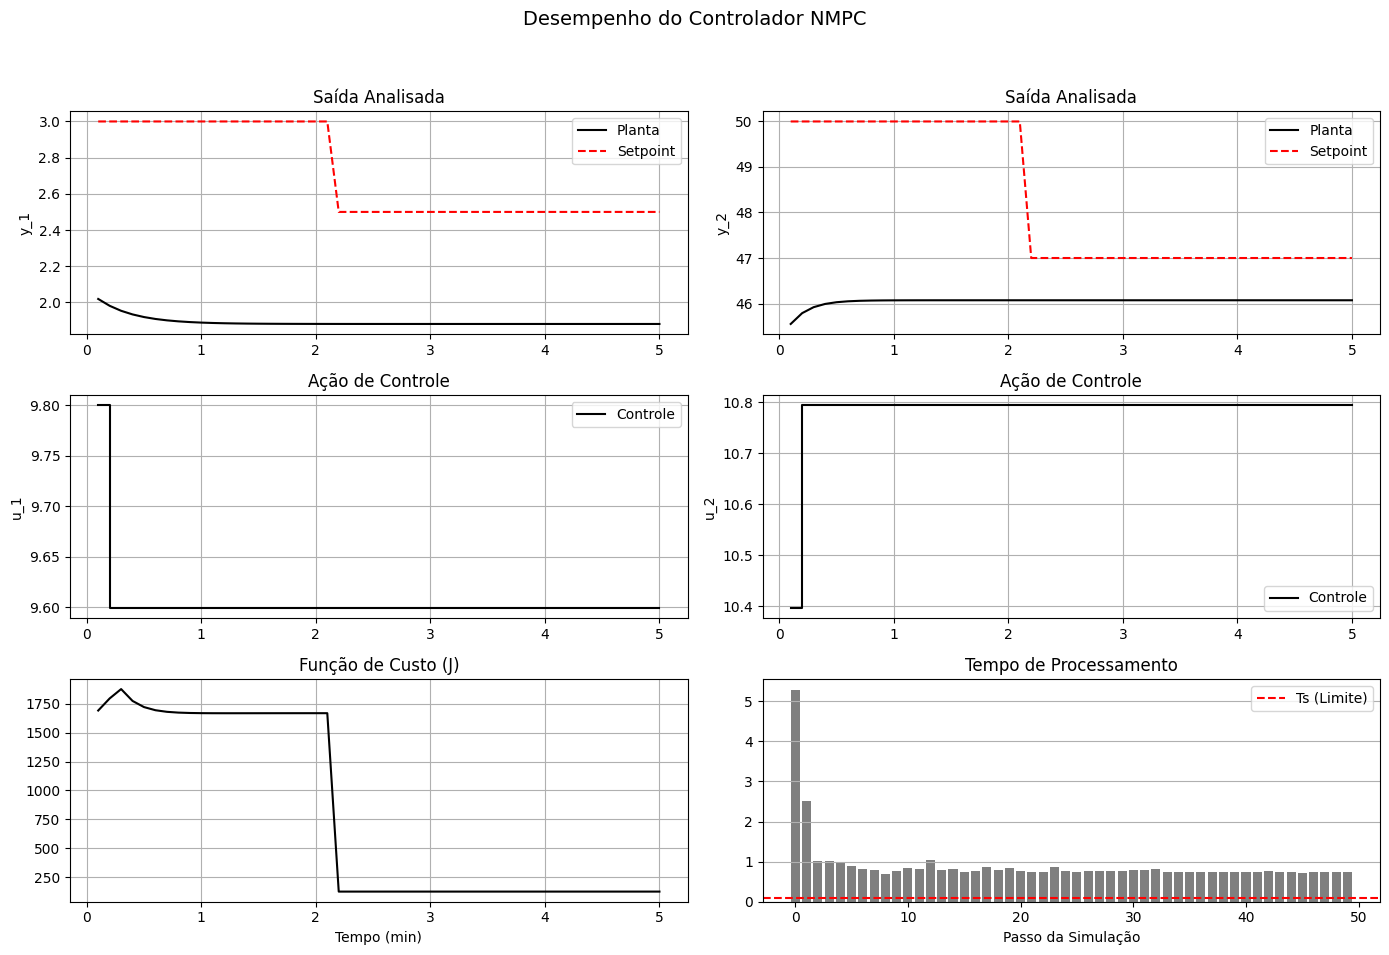

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------------------------------
# Gráficos
# --------------------------------------------------------------------------
history['yp'] = np.array(history['yp'])
history['uk'] = np.array(history['uk'])
history['sp'] = np.array(history['sp'])
history['cost'] = np.array(history['J'])
t_axis = np.linspace(Ts, nsim*Ts, nsim)

tempo_medio = np.mean(history['tcalc'])
tempo_max = np.max(history['tcalc'])
tempo_sum = np.sum(history['tcalc'])
print(f'Tempo Máximo[s] = ', tempo_max, '\nTempo Médio[s] = ', tempo_medio, '\nTempo Total[s] = ', tempo_sum)

fig, axs = plt.subplots(3, 2, figsize=(14, 10))
fig.suptitle('Desempenho do Controlador NMPC', fontsize=14)

# --- 1. SAÍDAS (y) ---
for i in range(ny):
    axs[0, i].plot(t_axis, history['yp'][:, i], 'k', label='Planta')
    axs[0, i].plot(t_axis, history['sp'][:, i], 'r--', label='Setpoint')
    axs[0, i].set_title(f'Saída Analisada')
    axs[0, i].set_ylabel(f'y_{i+1}')
    axs[0, i].grid(True)
    axs[0, i].legend()

# --- 2. ENTRADAS (u) ---
for i in range(nu):
    axs[1, i].step(t_axis, history['uk'][:, i], 'k', label='Controle', where='post')
    axs[1, i].set_title(f'Ação de Controle')
    axs[1, i].set_ylabel(f'u_{i+1}')
    axs[1, i].grid(True)
    axs[1, i].legend()

# --- 3. DESEMPENHO (Custo e Tempo) ---
# Gráfico de Custo
axs[2, 0].plot(t_axis, history['J'], 'k', label= 'Custo', linewidth=1.5)
axs[2, 0].set_title('Função de Custo (J)')
axs[2, 0].set_xlabel('Tempo (min)')
axs[2, 0].grid(True)

# Gráfico de Tempo de Cálculo
axs[2, 1].bar(range(nsim), history['tcalc'], color='k', alpha=0.5)
axs[2, 1].axhline(y=Ts, color='r', linestyle='--', label='Ts (Limite)')
axs[2, 1].set_title('Tempo de Processamento')
axs[2, 1].set_xlabel('Passo da Simulação')
axs[2, 1].legend()
axs[2, 1].grid(axis='y')

# Ajuste fino para não sobrepor títulos e eixos
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
plt.show()

# NMPC .ONNX

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import onnxruntime as ort

# --------------------------------------------------------------------------
# Modelos RNN
# --------------------------------------------------------------------------

# O 'sess' (sessão) substitui o 'model_rnn'
sess = ort.InferenceSession("model_JT.onnx")

# Obter o nome da entrada (necessário para o ONNX)
input_name = sess.get_inputs()[0].name

def rnn_predict_onnx(u_atual, session):
    # --- Normalização (Z-score conforme seu scaler) ---
    u_norm = std(u_atual)
    
    # --- Preparar o input para o ONNX ---
    # Garante float32 e o shape (1, 1, 2)
    input_data = u_norm.reshape(1, 1, 2).astype(np.float32)
    
    # --- Executar a Inferência ---
    # No ONNX, passamos um dicionário com o nome da entrada
    outputs = session.run(None, {input_name: input_data})
    ypred_norm = outputs[0] # O resultado vem em uma lista
    
    # --- Desnormalização ---
    return destd(ypred_norm.flatten())

# --------------------------------------------------------------------------
# Modelos Fenomenológico
# --------------------------------------------------------------------------
def jacketed_tank(x, t, u, m):
    L, T = x
    #Fin, Q = u
    Fi, Fv = u

    # Importando parâmetros
    At  = m['At']
    k   = m['k']
    rho = m['rho']
    Cp  = m['Cp']
    lmb = m['lambda']
    Ti  = m['Ti']

    # Modelo simplificado: Fout = k * sqrt(h)
    f1 = (Fi - k * np.sqrt(L)) / At
    f2 = (rho * Fi * Cp * (Ti - T) + Fv * lmb) / (rho * At * L * Cp)
    f = [f1 , f2]
    
    return f

In [88]:
import numpy as np

# --------------------------------------------------------------------------
# Função Objetivo do NMPC
# --------------------------------------------------------------------------
def fob_NMPC_RNN_onnx(du_flat, uk_1, Hp, Hc, ysp, q, r, x0m, x0, nu, sess, modelo):
    '''
    # TESTE DE MODELO
    u_atual = uk_1.copy()
    print(f'U =', u_atual)
    y1 = rnn_predict_onnx(u_atual, sess)
    print(f'Yrnn =', y1)
    y2 = odeint(jacketed_tank, x0, [0, 0.1], args=(u_atual, modelo))[-1, :]
    print(f'Yreal =', y2, '\n')
    '''
    # ---------
    du = du_flat.reshape((Hc, nu))
    cost = 0
    x_sim = x0m.copy() # Estado atual vindo do modelo/planta
    u_atual = uk_1.copy()
    x_next_m = rnn_predict_onnx(u_atual, sess)
    bias = x0 - x_next_m.flatten()
    # print(bias)
    for i in range(Hp):
        if i < Hc:
            u_atual = u_atual + du[i, :]
        
        # AQUI A MUDANÇA: Predição direta (1,1,2)
        # Note: Se sua RNN foi treinada com [u] ou [x, u], 
        # você deve incluir o 'u_atual' no input_data da rnn_predict
        y_sim = rnn_predict_onnx(u_atual, sess).flatten() + bias
        #y_sim = rnn_predict(u_atual, model_rnn)
        
        # Cálculo do erro
        error = (y_sim - ysp)
        error = error.flatten()
        #print(f'Erro', error.shape)
        #print(f'u_atual', u_atual)

        cost += error @ np.diag(q) @ error
        #cost += np.dot(error, np.dot(np.diag(q), error))
        #print(f'Cost', cost)
        if i < Hc:
            cost += np.dot(du[i, :], np.dot(np.diag(r), du[i, :]))
    #print(f"DU: {du_flat[:2]} | Cost: {cost}") # Descomente para ver se o custo muda
    return cost

In [92]:
import numpy as np

# --------------------------------------------------------------------------
# Parâmetros e Configurações
# --------------------------------------------------------------------------
modelo = {'rho': 1e3, 'Cp': 4.18, 'At': np.pi*0.5**2, 'k': 7, 'lambda': 2.257e4, 'Ti': 40}

nsim = 200
Hp, Hc = 10, 2
q = np.array([10, 10])
r = np.array([0.1, 0.1])
Ts = 0.1
nu, ny = 2, 2

# Restrições
umin = np.array([5, 5])
umax = np.array([20, 30])
dumax = np.array([1, 2])

# Condições iniciais
uk_1 = np.array([10.0, 10.0])
x0 = np.array([2.0408, 45.4])
x0m = x0.copy()
du0 = np.ones(Hc * nu) 

# Armazenamento de dados
history = {'yp': [], 'uk': [], 'sp': [], 'J': [], 'tcalc': [], 'nint': []}

In [93]:
import numpy as np
from scipy.optimize import minimize
from scipy.integrate import odeint
import time
    
# --------------------------------------------------------------------------
# Loop de Simulação
# --------------------------------------------------------------------------

for k in range(nsim):
    if(k<20):
        ysp = np.array([3.0, 40.0])
    if(20 < k < 100):
        ysp = np.array([2.5, 47.0])
    if(k>100):
        ysp = np.array([4.0, 48.0])
    
    # Restrições para o otimizador
    bounds = [(-dumax[i%nu], dumax[i%nu]) for i in range(Hc*nu)]
    constraints = {
    'type': 'ineq', 
    'fun': lambda du, uk_1, umin, umax: np.array([
        # Isso substitui o Bin = @(uk_1) [repmat(umax...)]
        *[(umax - (uk_1 + np.sum(du.reshape(Hc, nu)[:i+1, :], axis=0))).flatten() for i in range(Hc)],
        *[( (uk_1 + np.sum(du.reshape(Hc, nu)[:i+1, :], axis=0)) - umin).flatten() for i in range(Hc)]
    ]).flatten(),
    'args': (uk_1, umin, umax)
    }

    start_time = time.time() # 1 Marca o tempo de início
    res = minimize(fob_NMPC_RNN_onnx,
                   du0,
                   args=(uk_1, Hp, Hc, ysp, q, r, x0m, x0, nu, sess, modelo),
                   method='SLSQP', 
                   bounds=bounds,
                   constraints=constraints,
                   options={'eps': 1e-3})
    history['nint'].append(res.nit)
    history['tcalc'].append(time.time() - start_time) # 2 Calcula a diferença
    # print(res.x)
    du_opt = res.x.reshape((Hc, nu))
    uk_atual = uk_1 + du_opt[0, :]

    # Planta (Simulação real)
    mult = 1 if k < 80 else 1.0
    u_planta = uk_atual * mult
    x_next_p = odeint(jacketed_tank, x0, [0, Ts], args=(u_planta, modelo))[-1, :]

    # Ajuste de Entrada da RNN
    memory_buffer = uk_atual.copy()
    # Modelo (Simulação interna do controlador)
    #print(memory_buffer)
    #memory_buffer = memory_buffer.reshape(1, 2)
    x_next_m = rnn_predict_onnx(memory_buffer, sess)

    print(f'Iteração:', k)
    print(f'U =', u_planta)
    y1 = x_next_m
    print(f'Yrnn =', y1)
    y2 = x_next_p
    print(f'Yreal =', y2)
    print(f'YSP =', ysp, '\n')

    # Atualização
    history['yp'].append(x_next_p)
    history['uk'].append(uk_atual)
    history['sp'].append(ysp)
    history['J'].append(res.fun)
    
    x0, x0m, uk_1 = x_next_p, x_next_m, uk_atual
    du0 = np.concatenate([du_opt[1:], np.zeros((1, nu))]).flatten()

Iteração: 0
U = [10.99999999  8.00000001]
Yrnn = [ 2.41258662 43.95038738]
Yreal = [ 2.15033187 44.68251817]
YSP = [ 3. 40.] 

Iteração: 1
U = [11.99999999  6.00000001]
Yrnn = [ 2.86459485 42.78367136]
Yreal = [ 2.34126383 43.70495078]
YSP = [ 3. 40.] 

Iteração: 2
U = [12.99999999  5.00000001]
Yrnn = [ 3.33516657 42.1946319 ]
Yreal = [ 2.59476007 42.91021624]
YSP = [ 3. 40.] 

Iteração: 3
U = [13.99999999  5.        ]
Yrnn = [ 3.83610938 42.04460082]
Yreal = [ 2.89855548 42.44195869]
YSP = [ 3. 40.] 

Iteração: 4
U = [14.99999999  5.        ]
Yrnn = [ 4.3622251  41.90013756]
Yreal = [ 3.24471698 42.1449365 ]
YSP = [ 3. 40.] 

Iteração: 5
U = [15.40117869  5.        ]
Yrnn = [ 4.58383692 41.84706996]
Yreal = [ 3.56025417 41.97337938]
YSP = [ 3. 40.] 

Iteração: 6
U = [15.25018477  5.        ]
Yrnn = [ 4.49955122 41.86655998]
Yreal = [ 3.79213309 41.89011221]
YSP = [ 3. 40.] 

Iteração: 7
U = [14.75460943  5.        ]
Yrnn = [ 4.23006497 41.93436244]
Yreal = [ 3.92004428 41.86685294]
YS

Tempo Máximo[s] =  0.21980524063110352 
Tempo Médio[s] =  0.05060084581375122 
Tempo Total[s] =  10.120169162750244


C:\Users\allan\AppData\Local\Temp\ipykernel_30476\2247300257.py:54: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


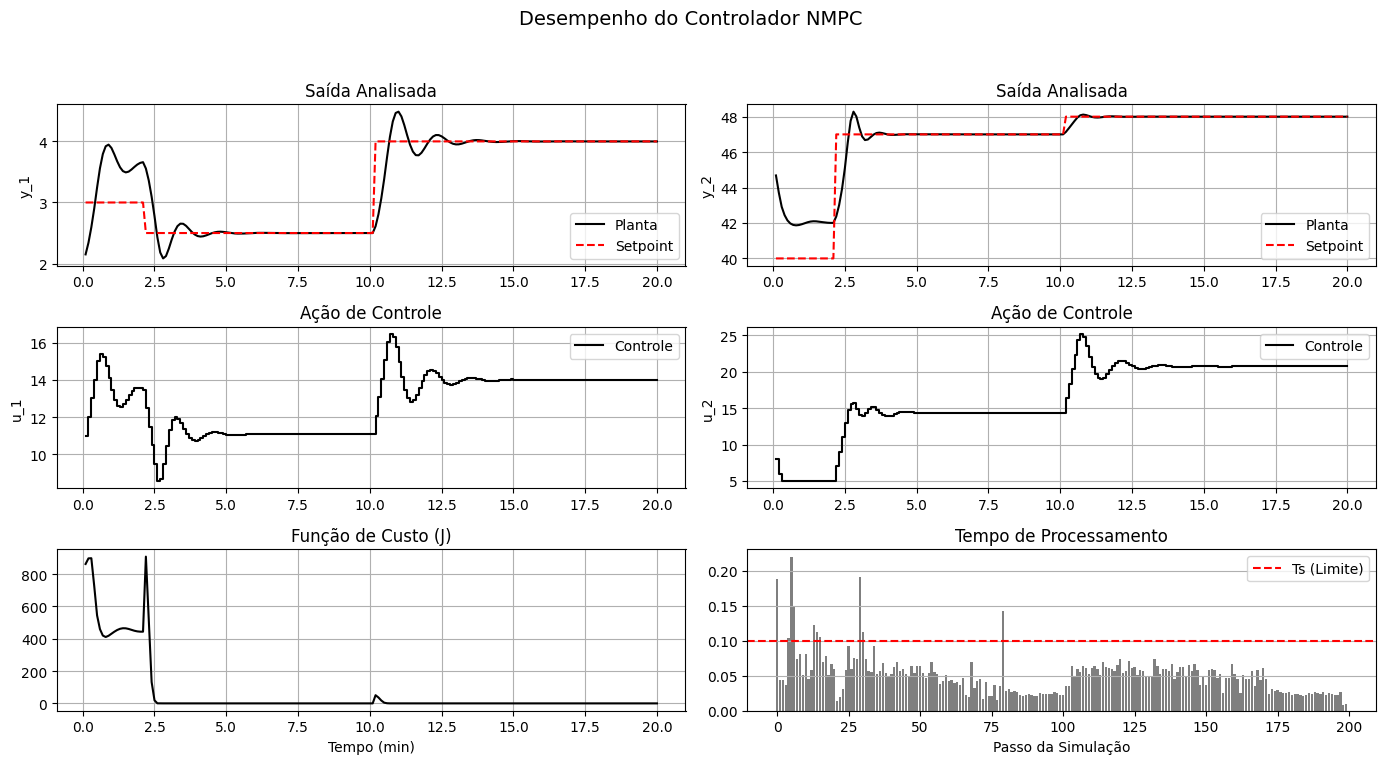

In [94]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------------------------------
# Gráficos
# --------------------------------------------------------------------------
history['yp'] = np.array(history['yp'])
history['uk'] = np.array(history['uk'])
history['sp'] = np.array(history['sp'])
history['cost'] = np.array(history['J'])
t_axis = np.linspace(Ts, nsim*Ts, nsim)

tempo_medio = np.mean(history['tcalc'])
tempo_max = np.max(history['tcalc'])
tempo_sum = np.sum(history['tcalc'])
print(f'Tempo Máximo[s] = ', tempo_max, '\nTempo Médio[s] = ', tempo_medio, '\nTempo Total[s] = ', tempo_sum)

fig, axs = plt.subplots(3, 2, figsize=(14, 8))
fig.suptitle('Desempenho do Controlador NMPC', fontsize=14)

# --- 1. SAÍDAS (y) ---
for i in range(ny):
    axs[0, i].plot(t_axis, history['yp'][:, i], 'k', label='Planta')
    axs[0, i].plot(t_axis, history['sp'][:, i], 'r--', label='Setpoint')
    axs[0, i].set_title(f'Saída Analisada')
    axs[0, i].set_ylabel(f'y_{i+1}')
    axs[0, i].grid(True)
    axs[0, i].legend()

# --- 2. ENTRADAS (u) ---
for i in range(nu):
    axs[1, i].step(t_axis, history['uk'][:, i], 'k', label='Controle', where='post')
    axs[1, i].set_title(f'Ação de Controle')
    axs[1, i].set_ylabel(f'u_{i+1}')
    axs[1, i].grid(True)
    axs[1, i].legend()

# --- 3. DESEMPENHO (Custo e Tempo) ---
# Gráfico de Custo
axs[2, 0].plot(t_axis, history['J'], 'k', label= 'Custo', linewidth=1.5)
axs[2, 0].set_title('Função de Custo (J)')
axs[2, 0].set_xlabel('Tempo (min)')
axs[2, 0].grid(True)

# Gráfico de Tempo de Cálculo
axs[2, 1].bar(range(nsim), history['tcalc'], color='k', alpha=0.5)
axs[2, 1].axhline(y=Ts, color='r', linestyle='--', label='Ts (Limite)')
axs[2, 1].set_title('Tempo de Processamento')
axs[2, 1].set_xlabel('Passo da Simulação')
axs[2, 1].legend()
axs[2, 1].grid(axis='y')

# Ajuste fino para não sobrepor títulos e eixos
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
plt.show()